<a href="https://colab.research.google.com/github/peterdomjan-maker/Biomed2026/blob/main/S4_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIOMED-DATA 26 · Session 4
## Ensembles: forests and boosting
**Random forest, gradient boosting, and explaining them with SHAP — predicting the diagnosis on UCI Heart**

> **STUDENT — fill in the blanks**
>
> Dataset: UCI Heart Disease (`ucimlrepo`, id=45). Runs in Colab: `Runtime → Run all`.
---

In [1]:
!pip -q install ucimlrepo scikit-learn shap pandas matplotlib

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score

## 0. Load, split, preprocess

In [3]:
heart = fetch_ucirepo(id=45)
X = heart.data.features.copy()
y = (heart.data.targets["num"] > 0).astype(int)
numeric = ["age","trestbps","chol","thalach","oldpeak"]
categorical = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pre = ColumnTransformer([
    ("num", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), numeric),
    ("cat", Pipeline([("i",SimpleImputer(strategy="most_frequent")),("o",OneHotEncoder(handle_unknown="ignore"))]), categorical),
])
def auc(model): return roc_auc_score(y_te, model.predict_proba(X_te)[:,1])

## 1. A single decision tree (and why it overfits)
A shallow tree is readable; a deep one memorises the training set. Compare a shallow and a deep tree.

In [4]:
from sklearn.tree import DecisionTreeClassifier

for depth in [1, None]:
    t = Pipeline([
        ("pre", pre),
        ("m", DecisionTreeClassifier(max_depth=depth, random_state=0))
    ]).fit(X_tr, y_tr)

    print(
        f"depth={str(depth):4s} "
        f"train AUC={roc_auc_score(y_tr, t.predict_proba(X_tr)[:, 1]):.3f} "
        f"test AUC={roc_auc_score(y_te, t.predict_proba(X_te)[:, 1]):.3f}"
    )

depth=1    train AUC=0.769 test AUC=0.721
depth=None train AUC=1.000 test AUC=0.762


## 2. Random forest (bagging)
Many deep trees on bootstrap samples, then vote. More trees never overfit a forest; they steady it.

In [5]:
from sklearn.ensemble import RandomForestClassifier

# TODO: 300 trees, random_state=0
rf = Pipeline([
    ("pre", pre),
    ("m", RandomForestClassifier(n_estimators=300, random_state=0))
]).fit(X_tr, y_tr)

print("Random forest test AUC:", round(auc(rf), 3))

Random forest test AUC: 0.943


## 3. Gradient boosting
Shallow trees in sequence, each correcting the last. Usually the strongest on tabular data.

In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier
gb = Pipeline([("pre",pre),("m",HistGradientBoostingClassifier(learning_rate=0.05, max_iter=400,
              early_stopping=True, random_state=0))]).fit(X_tr,y_tr)
print("Gradient boosting test AUC:", round(auc(gb),3))

Gradient boosting test AUC: 0.96


## 4. Compare against the Session 2 baseline
Same data, same preprocessing. How much do the ensembles add over logistic regression?

In [7]:
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Random forest": RandomForestClassifier(n_estimators=300, random_state=0),
    "Gradient boosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=400,
        early_stopping=True,
        random_state=0
    ),
}

for name, m in models.items():
    # 5-fold CV AUC on the training data
    cv = cross_val_score(
        Pipeline([
            ("pre", pre),
            ("m", m)
        ]),
        X_tr,
        y_tr,
        cv=5,
        scoring="roc_auc"
    ).mean()

    print(f"{name:18s} CV-AUC = {cv:.3f}")

Logistic           CV-AUC = 0.894
Random forest      CV-AUC = 0.895
Gradient boosting  CV-AUC = 0.885


## 5. Feature importance (with a caution)
The built-in importance is fast but biased. Permutation importance, measured on held-out data, is fairer.

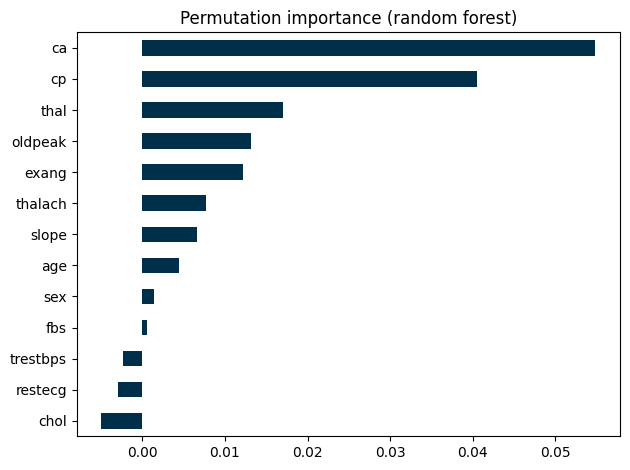

In [8]:
from sklearn.inspection import permutation_importance

# TODO: permutation importance of rf on the TEST set, scoring="roc_auc"
r = permutation_importance(
    rf,
    X_te,
    y_te,
    n_repeats=20,
    random_state=0,
    scoring="roc_auc"
)

imp = pd.Series(
    r.importances_mean,
    index=X.columns
).sort_values()

imp.plot.barh(color="#003049")
plt.title("Permutation importance (random forest)")
plt.tight_layout()
plt.show()

## 6. Explaining the ensemble with SHAP
SHAP gives fair, per-patient contributions. TreeSHAP is fast for forests and boosting.
> If SHAP hiccups on your version, the permutation importance above is a solid fallback.

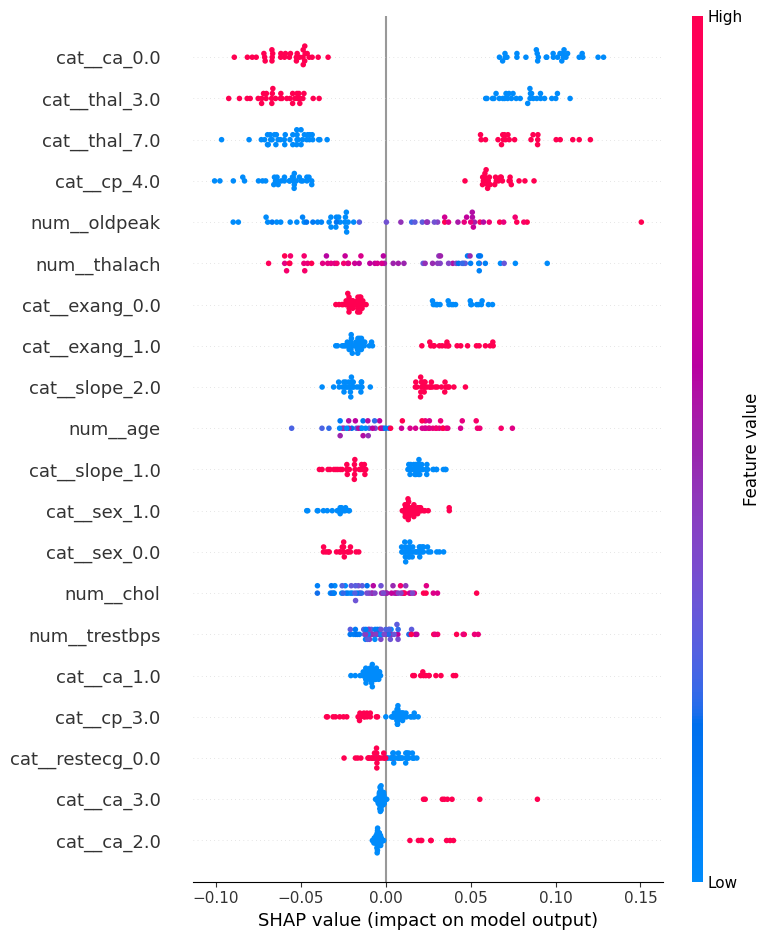

In [10]:
import shap

Xt_tr = pre.fit_transform(X_tr)
Xt_te = pre.transform(X_te)

Xt_tr = Xt_tr.toarray() if hasattr(Xt_tr, "toarray") else Xt_tr
Xt_te = Xt_te.toarray() if hasattr(Xt_te, "toarray") else Xt_te

rf2 = RandomForestClassifier(n_estimators=300, random_state=0).fit(Xt_tr, y_tr)

explainer = shap.TreeExplainer(rf2)
sv = explainer.shap_values(Xt_te)

# Binary classification esetén gyakran listát ad: [class 0, class 1]
if isinstance(sv, list):
    sv = sv[1]

# Ha 3D tömböt adna, vegyük a pozitív osztályt
if len(sv.shape) == 3:
    sv = sv[:, :, 1]

feat_names = pre.get_feature_names_out()

shap.summary_plot(
    sv,
    Xt_te,
    feature_names=feat_names,
    plot_type="dot",
    show=True
)

## 7. One patient, explained
A SHAP waterfall for a single test patient: which features pushed the risk up (red) or down (blue).

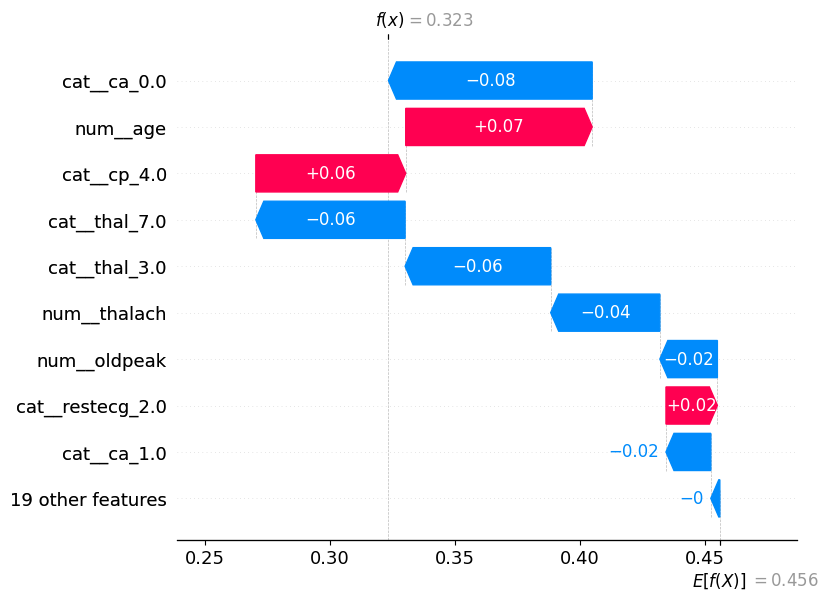

In [11]:
# (Given) a per-patient explanation
shap.plots._waterfall.waterfall_legacy(explainer.expected_value[1], sv[0], feature_names=feat_names, show=True)

## Questions to think about
1. How big was the gap between the deep tree's train and test AUC? What does that gap mean?
2. Did boosting clearly beat the logistic baseline on this small dataset, or only slightly?
3. Do the top SHAP features match the permutation-importance ranking? Where do they disagree, and why might that be?
